### Set Up Your Environment

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


### Load the Dataset

In [3]:

df = pd.read_excel('Credit_Risk_Dataset.xlsx')


In [4]:

# Preview

pd.set_option('display.max_columns', None)
df.head()


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


In [5]:

# Structure
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  str    
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  str    
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  str    
 6   loan_grade                  32581 non-null  str    
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  str    
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      32581 non-null

In [6]:

# Summary stats
df.describe()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,45.407613,-63.805473,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001,7.644809,46.615580,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,29.760400,-123.365600,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,40.712800,-96.797000,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,46.813900,-75.697200,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000,51.507400,-3.943600,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,55.953300,-0.127800,60.000000,0.830000,1.187999e+06,1.053888,15.000000,0.949998,6.000000



Necessary to describe ??
city_latitude	
city_longitude



Correct Format:
person_income format
other_debt format
loan_status should be categorical



Missing values:
loan_int_rate
person_emp_length



### Data Cleaning

In [7]:
df.isnull().sum()

client_ID                        0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
gender                           0
marital_status                   0
education_level                  0
country                          0
state                            0
city                             0
city_latitude                    0
city_longitude                   0
employment_type                  0
loan_term_months                 0
loan_to_income_ratio             0
other_debt                       0
debt_to_income_ratio             0
open_accounts                    0
credit_utilization_ratio         0
past_delinquencies  


Missing Values: from df.isnull().sum()

person_emp_length              895

loan_int_rate                 3116

In [8]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [9]:
df['loan_status'] = df['loan_status'].astype('category')

In [10]:
df['person_income'] = df['person_income'].astype(int)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [11]:


df['other_debt'] = df['other_debt'].astype(int)
pd.set_option('display.float_format', '{:,.2f}'.format)


In [12]:


df.duplicated().sum()
# df = df.drop_duplicates()


np.int64(0)

In [13]:
# Summary stats
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,"32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00","32,581.00"
mean,27.73,"66,074.85",4.77,"9,589.37",11.01,0.17,5.80,45.41,-63.81,38.50,0.17,"11,567.46",0.35,8.04,0.50,0.51
std,6.35,"61,983.12",4.09,"6,322.09",3.08,0.11,4.06,7.64,46.62,16.01,0.11,"13,060.93",0.13,4.33,0.26,0.71
min,20.00,"4,000.00",0.00,500.00,5.42,0.00,2.00,29.76,-123.37,12.00,0.00,225.00,0.06,0.00,0.05,0.00
25%,23.00,"38,500.00",2.00,"5,000.00",8.49,0.09,3.00,40.71,-96.80,24.00,0.09,"5,387.00",0.25,4.00,0.28,0.00
50%,26.00,"55,000.00",4.00,"8,000.00",10.99,0.15,4.00,46.81,-75.70,36.00,0.15,"8,995.00",0.33,8.00,0.50,0.00
75%,30.00,"79,200.00",7.00,"12,200.00",13.11,0.23,8.00,51.51,-3.94,60.00,0.23,"14,562.00",0.42,12.00,0.73,1.00
max,144.00,"6,000,000.00",123.00,"35,000.00",23.22,0.83,30.00,55.95,-0.13,60.00,0.83,"1,187,998.00",1.05,15.00,0.95,6.00


C:\Users\kwart\AppData\Local\Temp\ipykernel_21512\1832158909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


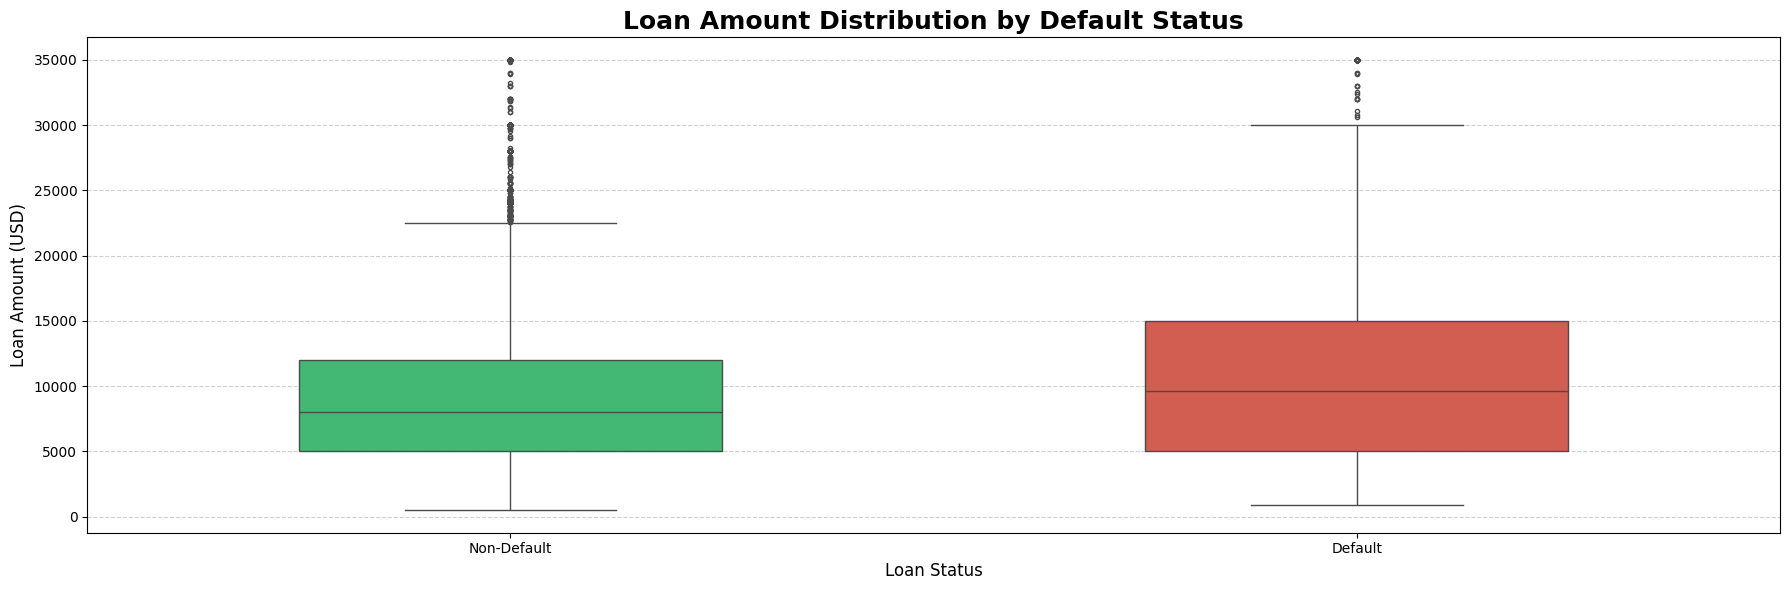

In [14]:

plt.figure(figsize=(18, 6))

sns.boxplot(
    x='loan_status',
    y='loan_amnt',
    # hue='loan_status',              
    data=df,
    palette=['#2ECC71', '#E74C3C'],
    width=0.5,
    fliersize=3,
    legend=False                   
)

# Titles and labels
plt.title('Loan Amount Distribution by Default Status', fontsize=18, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Loan Amount (USD)', fontsize=12)

# Rename x-axis labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


C:\Users\kwart\AppData\Local\Temp\ipykernel_21512\3996787633.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


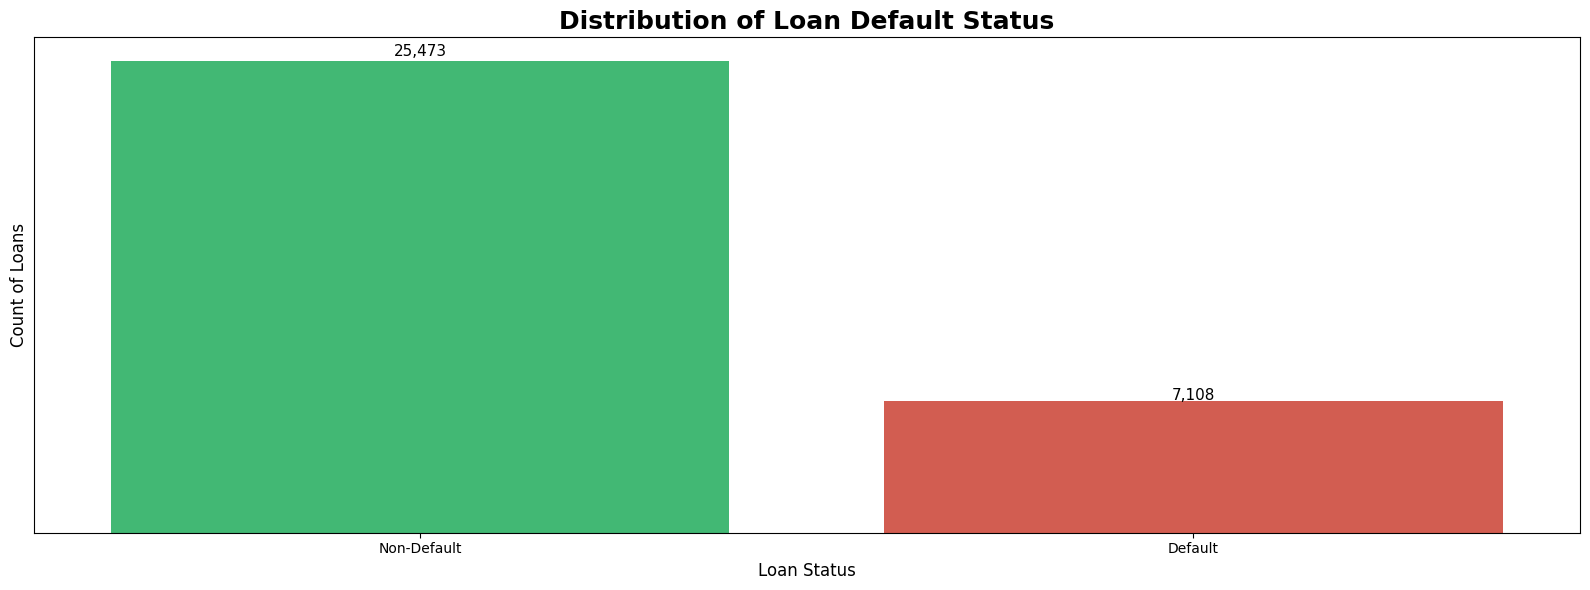

In [15]:
plt.figure(figsize=(16, 6))

sns.countplot(
    x='loan_status',
    # hue='loan_status',
    data=df,
    palette=['#2ECC71', '#E74C3C'],
    # palette='Blues_r',
    legend=False
)

# Titles and labels
plt.title('Distribution of Loan Default Status', fontsize=18, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count of Loans', fontsize=12)

# Rename x-axis labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# Remove y-axis ticks (numbers)
plt.yticks([])

# Keep grid subtle (optional: you can remove it too)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add data labels
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width()/2,
        height + (height * 0.01),
        f'{int(height):,}',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

<!-- ### Univariate Analysis (Understand Each Variable) -->

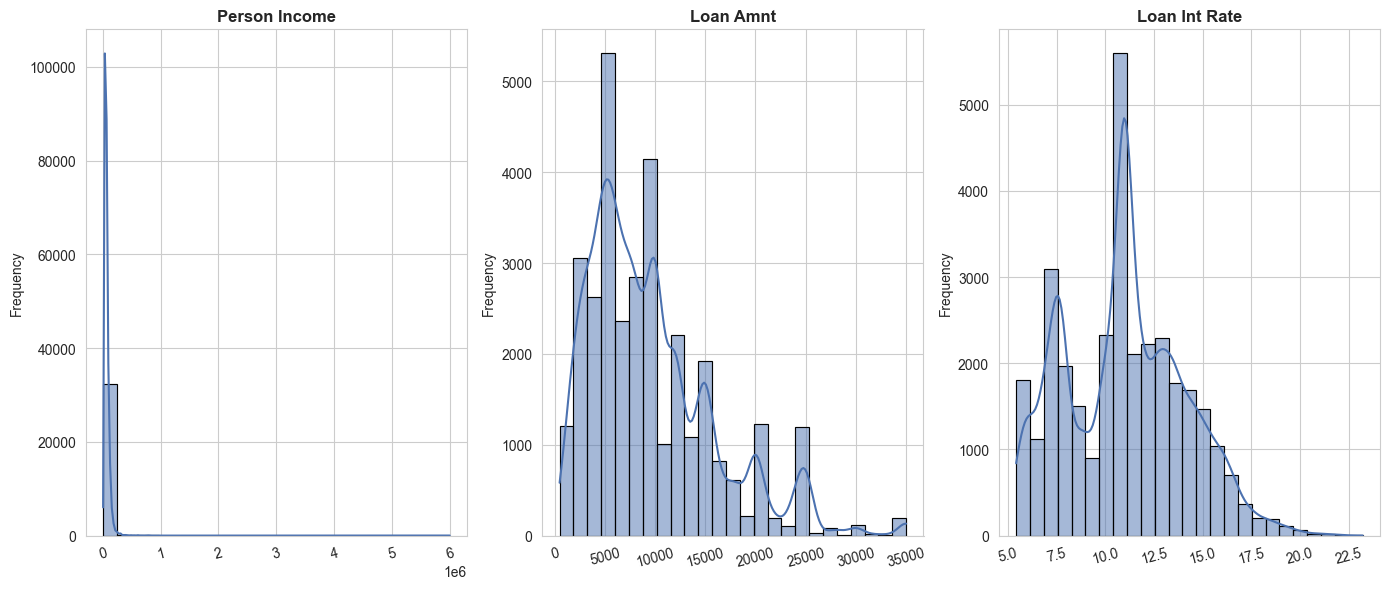

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

columns = ['person_income', 'loan_amnt', 'loan_int_rate']

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sns.histplot(
        df[col],
        bins=25,
        kde=True,
        color="#4C72B0",  # histogram bar color
        edgecolor='black',
        alpha=0.5,
        # line_kws={'color':'#E74C3C', 'linewidth':2}  
    )
    plt.title(col.replace("_", " ").title(), fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Frequency')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

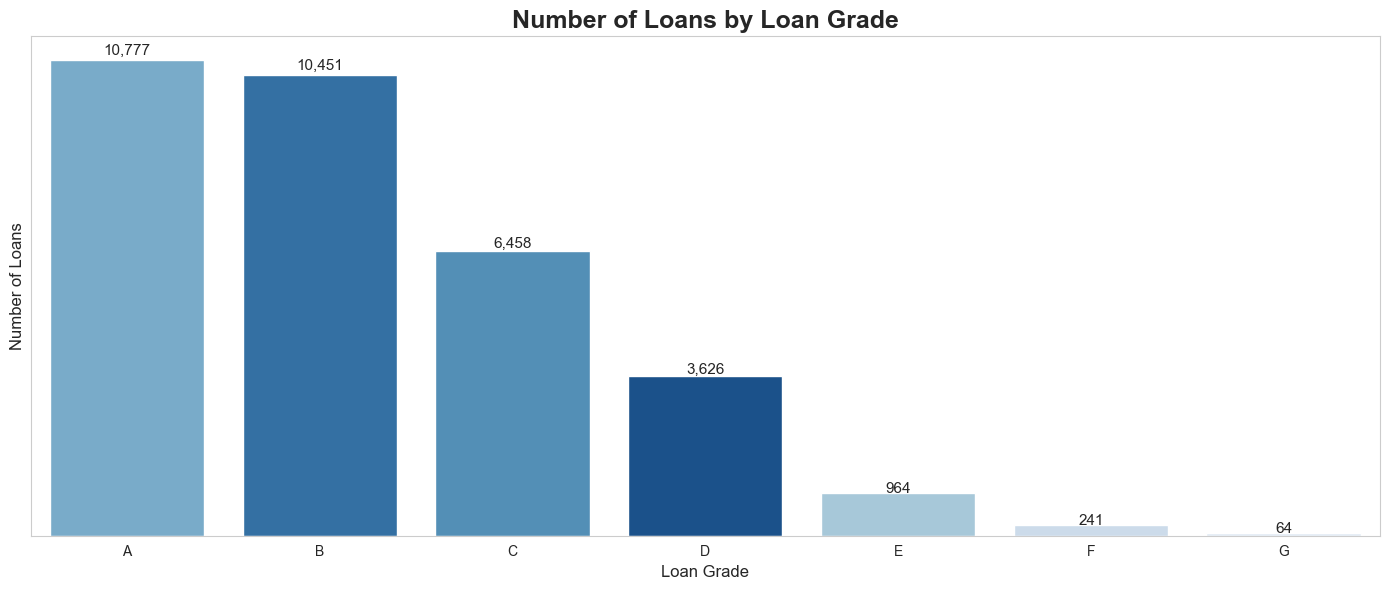

In [17]:


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# Countplot with hue to satisfy Seaborn 0.14+
sns.countplot(
    x='loan_grade',
    hue='loan_grade',                 
    data=df,
    palette='Blues_r',
    order=sorted(df['loan_grade'].unique()),
    legend=False                      
)

# Titles and labels
plt.title('Number of Loans by Loan Grade', fontsize=18, fontweight='bold')
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Number of Loans', fontsize=12)

# Remove y-axis ticks (numbers) for cleaner look
plt.yticks([])

# Add subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add data labels on top of bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width()/2,
        height + (height * 0.01),
        f'{int(height):,}',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Bivariate Analysis

In [18]:
import pandas as pd

# Count of loans per grade
loan_counts = df['loan_grade'].value_counts().sort_index()

# Normalized crosstab for default rates
loan_grade_default = pd.crosstab(
    df['loan_grade'],
    df['loan_status'],
    normalize='index'
)

# Rename columns
loan_grade_default.columns = ['Non-Default', 'Default']

# Add loan counts as a new column
loan_grade_default['Count'] = loan_counts

# Reorder columns (Count first if desired)
loan_grade_default = loan_grade_default[['Count', 'Non-Default', 'Default']]

# Style table
loan_grade_default = loan_grade_default.style.format({
    'Count': '{:,}',        # format count with commas
    'Non-Default': '{:.2%}',
    'Default': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default']) \
    .set_caption("Loan Grade Summary: Count & Default Rates") \
    .set_table_styles([
    {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center'), ('min-width', '220px')]},
    {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

loan_grade_default

,Count,Non-Default,Default
loan_grade,,,
A,"10,777",90.04%,9.96%
B,"10,451",83.72%,16.28%
C,"6,458",79.27%,20.73%
D,"3,626",40.95%,59.05%
E,964,35.58%,64.42%
F,241,29.46%,70.54%
G,64,1.56%,98.44%


In [19]:
import pandas as pd

# Step 1: Crosstab (counts)
table = pd.crosstab(
    df['person_home_ownership'],
    df['loan_status']
)

# Rename columns
table.columns = ['Non-Default', 'Default']

# Step 2: Total
table['Count (Total)'] = table.sum(axis=1)

# Step 3: Percentages
table['Non-Default (%)'] = table['Non-Default'] / table['Count (Total)']
table['Default (%)'] = table['Default'] / table['Count (Total)']

# Step 4: Select required columns
table = table[['Count (Total)', 'Non-Default (%)', 'Default (%)']]

# Step 5: Sort by risk
table = table.sort_values(by='Default (%)', ascending=False)

# Step 6: Style (ONLY Default % highlighted)
table = table.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Home Ownership vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table

,Count (Total),Non-Default (%),Default (%)
person_home_ownership,,,
RENT,"16,446",68.43%,31.57%
OTHER,107,69.16%,30.84%
MORTGAGE,"13,444",87.43%,12.57%
OWN,"2,584",92.53%,7.47%


In [20]:


import pandas as pd

# Step 1: Crosstab (counts)
table_intent = pd.crosstab(
    df['loan_intent'],
    df['loan_status']
)

# Rename columns
table_intent.columns = ['Non-Default', 'Default']

# Step 2: Total count
table_intent['Count (Total)'] = table_intent.sum(axis=1)

# Step 3: Percentages
table_intent['Non-Default (%)'] = table_intent['Non-Default'] / table_intent['Count (Total)']
table_intent['Default (%)'] = table_intent['Default'] / table_intent['Count (Total)']

# Step 4: Keep only required columns
table_intent = table_intent[['Count (Total)', 'Non-Default (%)', 'Default (%)']]

# Step 5: Sort by risk
table_intent = table_intent.sort_values(by='Default (%)', ascending=False)

# Step 6: Style (highlight only Default %)
table_intent = table_intent.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Loan Purpose vs Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_intent


,Count (Total),Non-Default (%),Default (%)
loan_intent,,,
DEBTCONSOLIDATION,"5,212",71.41%,28.59%
MEDICAL,"6,071",73.30%,26.70%
HOMEIMPROVEMENT,"3,605",73.90%,26.10%
PERSONAL,"5,521",80.11%,19.89%
EDUCATION,"6,453",82.78%,17.22%
VENTURE,"5,719",85.19%,14.81%


In [21]:
import pandas as pd

# Step 1: Crosstab (counts)
table_default_hist = pd.crosstab(
    df['cb_person_default_on_file'],
    df['loan_status']
)

# Rename columns
table_default_hist.columns = ['Non-Default', 'Default']

# Step 2: Total count
table_default_hist['Count (Total)'] = table_default_hist.sum(axis=1)

# Step 3: Percentages
table_default_hist['Non-Default (%)'] = (
    table_default_hist['Non-Default'] / table_default_hist['Count (Total)']
)
table_default_hist['Default (%)'] = (
    table_default_hist['Default'] / table_default_hist['Count (Total)']
)

# Step 4: Keep only required columns
table_default_hist = table_default_hist[['Count (Total)', 'Non-Default (%)', 'Default (%)']]

# Step 5: Sort by risk
table_default_hist = table_default_hist.sort_values(by='Default (%)', ascending=False)

# Step 6: Rename index for clarity
table_default_hist.index = table_default_hist.index.map({'Y': 'Yes', 'N': 'No'})

# Step 7: Style (highlight only Default %)
table_default_hist = table_default_hist.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Previous Default History vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_default_hist

,Count (Total),Non-Default (%),Default (%)
cb_person_default_on_file,,,
Yes,"5,745",62.19%,37.81%
No,"26,836",81.61%,18.39%


In [22]:
import pandas as pd

# Step 1: Crosstab (counts)
table_gender = pd.crosstab(
    df['gender'],
    df['loan_status']
)

# Rename columns
table_gender.columns = ['Non-Default', 'Default']

# Step 2: Total count
table_gender['Count (Total)'] = table_gender.sum(axis=1)

# Step 3: Percentages
table_gender['Non-Default (%)'] = (
    table_gender['Non-Default'] / table_gender['Count (Total)']
)
table_gender['Default (%)'] = (
    table_gender['Default'] / table_gender['Count (Total)']
)

# Step 4: Keep only required columns
table_gender = table_gender[['Count (Total)', 'Non-Default (%)', 'Default (%)']]

# Step 5: Sort by risk
table_gender = table_gender.sort_values(by='Default (%)', ascending=False)

# Step 6: Style (highlight only Default %)
table_gender = table_gender.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Gender vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_gender

,Count (Total),Non-Default (%),Default (%)
gender,,,
Female,"16,210",78.13%,21.87%
Male,"16,371",78.24%,21.76%


In [23]:


import pandas as pd

# Step 1: Crosstab (counts)
table_marital = pd.crosstab(
    df['marital_status'],
    df['loan_status']
)

# Rename columns
table_marital.columns = ['Non-Default', 'Default']

# Step 2: Total count
table_marital['Count (Total)'] = table_marital.sum(axis=1)

# Step 3: Percentages
table_marital['Non-Default (%)'] = (
    table_marital['Non-Default'] / table_marital['Count (Total)']
)
table_marital['Default (%)'] = (
    table_marital['Default'] / table_marital['Count (Total)']
)

# Step 4: Keep only required columns
table_marital = table_marital[['Count (Total)', 'Non-Default (%)', 'Default (%)']]

# Step 5: Sort by risk
table_marital = table_marital.sort_values(by='Default (%)', ascending=False)

# Step 6: Style (highlight only Default %)
table_marital = table_marital.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Marital Status vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_marital

,Count (Total),Non-Default (%),Default (%)
marital_status,,,
Married,"11,393",78.04%,21.96%
Divorced,"3,173",78.19%,21.81%
Single,"16,368",78.24%,21.76%
Widowed,"1,647",78.63%,21.37%


In [24]:

import pandas as pd

# Step 1: Crosstab (counts)
table_education = pd.crosstab(
    df['education_level'],
    df['loan_status']
)

# Rename columns
table_education.columns = ['Non-Default', 'Default']

# Step 2: Total count
table_education['Count (Total)'] = table_education.sum(axis=1)

# Step 3: Percentages
table_education['Non-Default (%)'] = (
    table_education['Non-Default'] / table_education['Count (Total)']
)
table_education['Default (%)'] = (
    table_education['Default'] / table_education['Count (Total)']
)

# Step 4: Keep only required columns
table_education = table_education[['Count (Total)', 'Non-Default (%)', 'Default (%)']]

# Step 5: Sort by risk
table_education = table_education.sort_values(by='Default (%)', ascending=False)

# Step 6: Style (highlight only Default %)
table_education = table_education.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Education Level vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_education

,Count (Total),Non-Default (%),Default (%)
education_level,,,
Master,"6,508",77.83%,22.17%
High School,"13,185",77.94%,22.06%
Bachelor,"11,390",78.59%,21.41%
PhD,"1,498",78.84%,21.16%


In [25]:





# Crosstab (counts)
table_country = pd.crosstab(
    df['country'],
    df['loan_status']
)

# Rename columns
table_country.columns = ['Non-Default', 'Default']

# Total count
table_country['Count (Total)'] = table_country.sum(axis=1)

# Percentages
table_country['Non-Default (%)'] = (
    table_country['Non-Default'] / table_country['Count (Total)']
)
table_country['Default (%)'] = (
    table_country['Default'] / table_country['Count (Total)']
)

# Keep only required columns
table_country = table_country[['Count (Total)', 'Non-Default (%)', 'Default (%)']]
# Sort by risk
table_country = table_country.sort_values(by='Default (%)', ascending=False)

# Style (highlight only Default %)
table_country = table_country.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Country vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_country

,Count (Total),Non-Default (%),Default (%)
country,,,
Canada,"10,785",78.14%,21.86%
USA,"10,852",78.14%,21.86%
UK,"10,944",78.27%,21.73%


In [26]:


# Crosstab (counts)
table_state = pd.crosstab(
    df['state'],
    df['loan_status']
)

# Rename columns
table_state.columns = ['Non-Default', 'Default']

# Total count
table_state['Count (Total)'] = table_state.sum(axis=1)

# Percentages
table_state['Non-Default (%)'] = (
    table_state['Non-Default'] / table_state['Count (Total)']
)
table_state['Default (%)'] = (
    table_state['Default'] / table_state['Count (Total)']
)

# Keep only required columns
table_state = table_state[['Count (Total)', 'Non-Default (%)', 'Default (%)']]
# Sort by risk
table_state = table_state.sort_values(by='Default (%)', ascending=False)

# Style (highlight only Default %)
table_state = table_state.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("State vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_state

,Count (Total),Non-Default (%),Default (%)
state,,,
Scotland,"3,648",77.49%,22.51%
BC,"3,679",77.52%,22.48%
California,"3,679",77.66%,22.34%
Texas,"3,608",77.77%,22.23%
Ontario,"3,553",78.10%,21.90%
England,"3,654",78.19%,21.81%
Quebec,"3,553",78.81%,21.19%
New York,"3,565",79.02%,20.98%
Wales,"3,642",79.13%,20.87%


In [27]:





# Crosstab (counts)
table_employment_type = pd.crosstab(
    df['employment_type'],
    df['loan_status']
)

# Rename columns
table_employment_type.columns = ['Non-Default', 'Default']

# Total count
table_employment_type['Count (Total)'] = table_employment_type.sum(axis=1)

# Percentages
table_employment_type['Non-Default (%)'] = (
    table_employment_type['Non-Default'] / table_employment_type['Count (Total)']
)
table_employment_type['Default (%)'] = (
    table_employment_type['Default'] / table_employment_type['Count (Total)']
)

# Keep only required columns
table_employment_type = table_employment_type[['Count (Total)', 'Non-Default (%)', 'Default (%)']]
# Sort by risk
table_employment_type = table_employment_type.sort_values(by='Default (%)', ascending=False)

# Style (highlight only Default %)
table_employment_type = table_employment_type.style \
    .format({
        'Count (Total)': '{:,}',
        'Non-Default (%)': '{:.2%}',
        'Default (%)': '{:.2%}'
    }) \
    .background_gradient(cmap='RdYlGn_r', subset=['Default (%)']) \
    .set_caption("Employment Type vs Loan Default Distribution") \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '14pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('min-width', '220px')]}
    ])

table_employment_type

,Count (Total),Non-Default (%),Default (%)
employment_type,,,
Unemployed,"1,672",77.33%,22.67%
Self-employed,"4,926",77.51%,22.49%
Part-time,"6,510",78.17%,21.83%
Full-time,"19,473",78.43%,21.57%


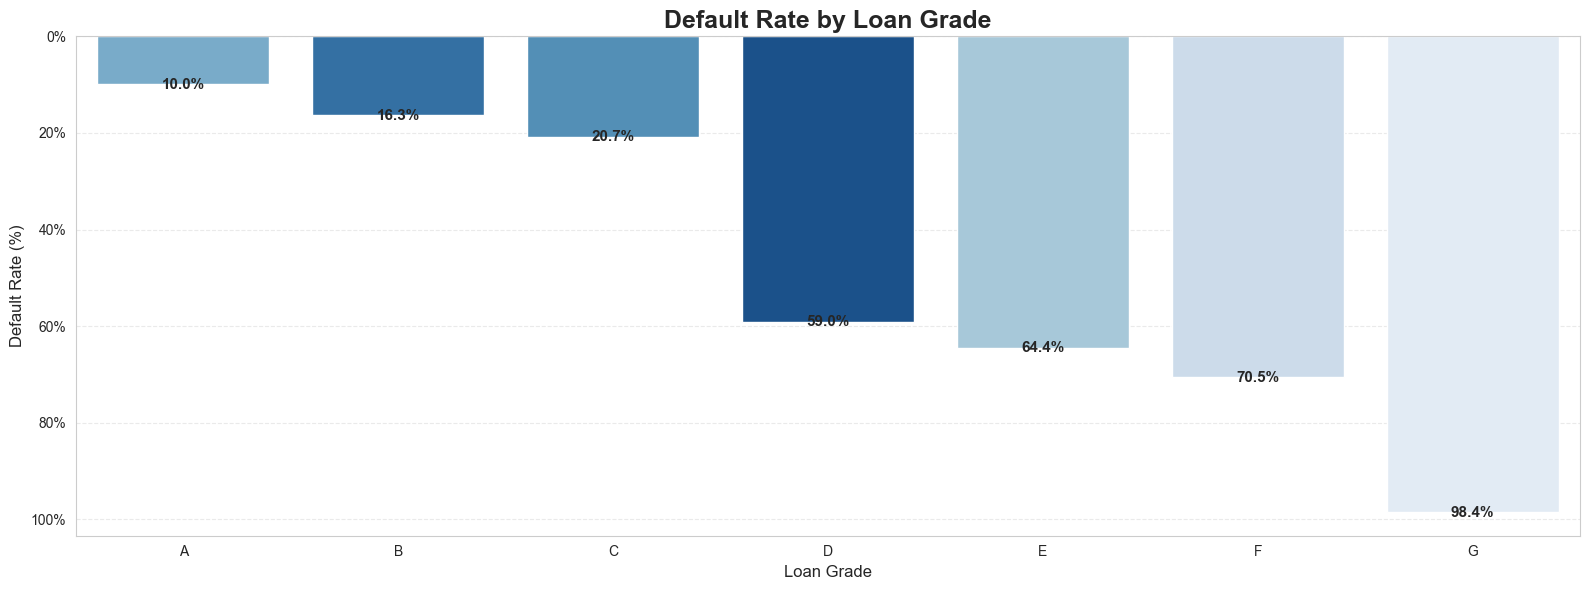

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

sns.barplot(
    x='loan_grade',
    y='loan_status',
    data=df,
    hue='loan_grade',
    palette='Blues_r',
    order=sorted(df['loan_grade'].unique()),
    legend=False,
    errorbar=None
)

plt.title("Default Rate by Loan Grade", fontsize=18, fontweight='bold')
plt.xlabel("Loan Grade", fontsize=12)
plt.ylabel("Default Rate (%)", fontsize=12)

# Ensure correct direction
# plt.gca().invert_yaxis(False)

# Format y-axis
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Labels
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width()/2,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )




plt.tight_layout()
plt.show()

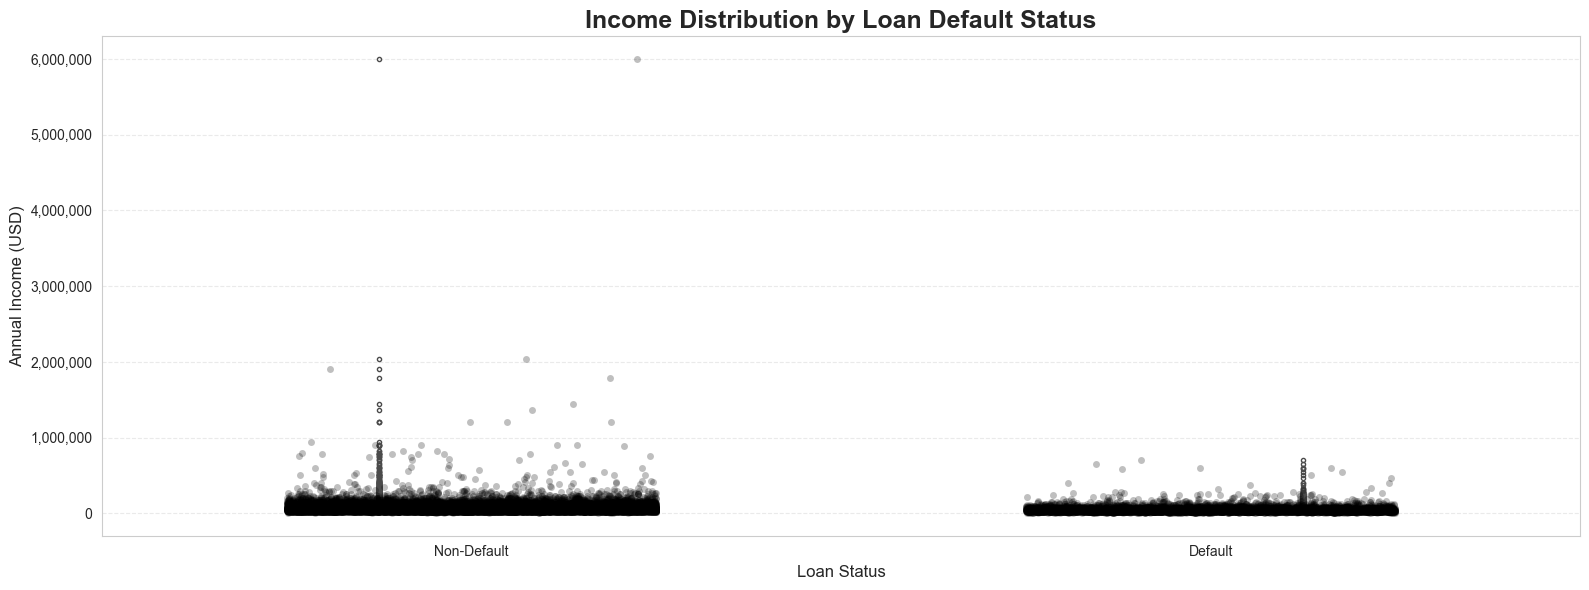

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

# Boxplot
sns.boxplot(
    x='loan_status',
    y='person_income',
    hue='loan_status',                # fixes seaborn warning
    data=df,
    palette=['#2ECC71', '#E74C3C'],   # green = non-default, red = default
    width=0.5,
    fliersize=3,
    legend=False
)

# Overlay data points
sns.stripplot(
    x='loan_status',
    y='person_income',
    data=df,
    color='black',
    alpha=0.25,
    jitter=0.25
)

# Titles and labels
plt.title('Income Distribution by Loan Default Status', fontsize=18, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Annual Income (USD)', fontsize=12)

# Rename x-axis labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\kwart\AppData\Local\Temp\ipykernel_21512\3408671283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


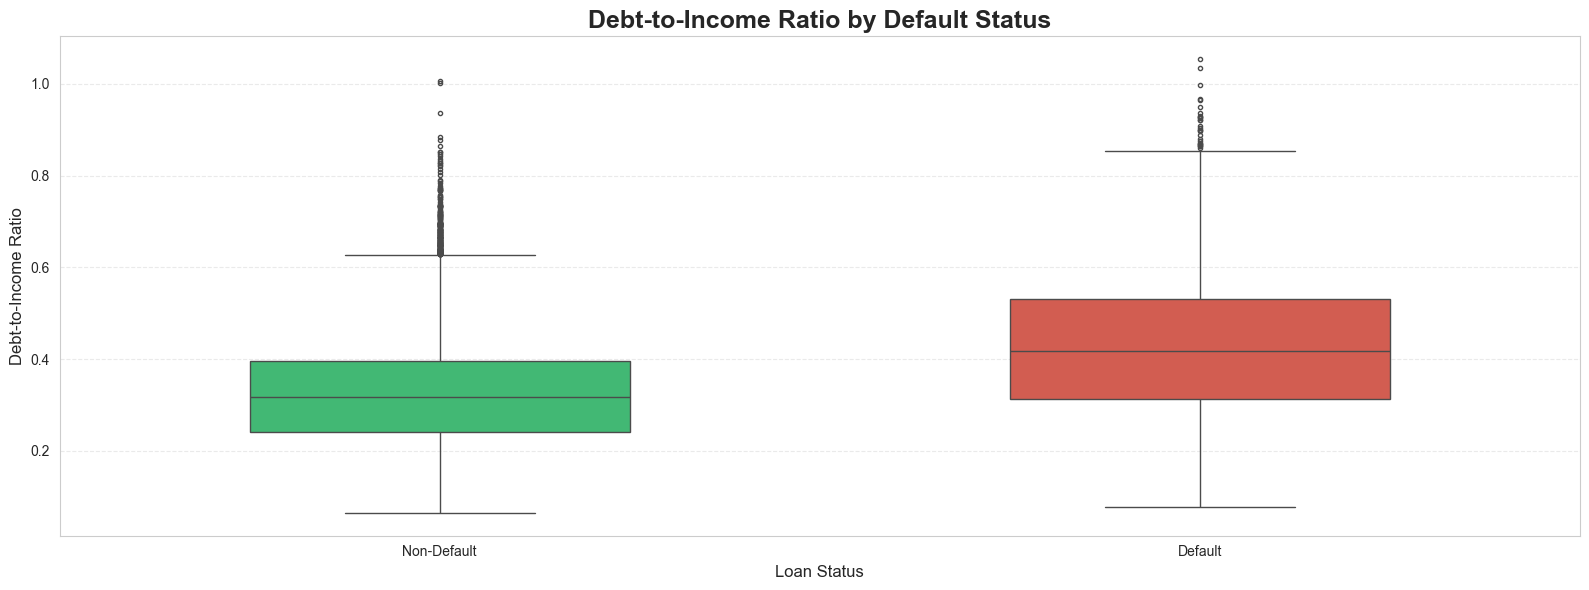

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

# Boxplot
sns.boxplot(
    x='loan_status',
    y='debt_to_income_ratio',
    # hue='loan_status',                 # fixes seaborn warning
    data=df,
    palette=['#2ECC71', '#E74C3C'],    # green = safe, red = risky
    width=0.5,
    fliersize=3,
    legend=False
)



# Titles and labels
plt.title('Debt-to-Income Ratio by Default Status', fontsize=18, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Debt-to-Income Ratio', fontsize=12)

# Rename x-axis labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

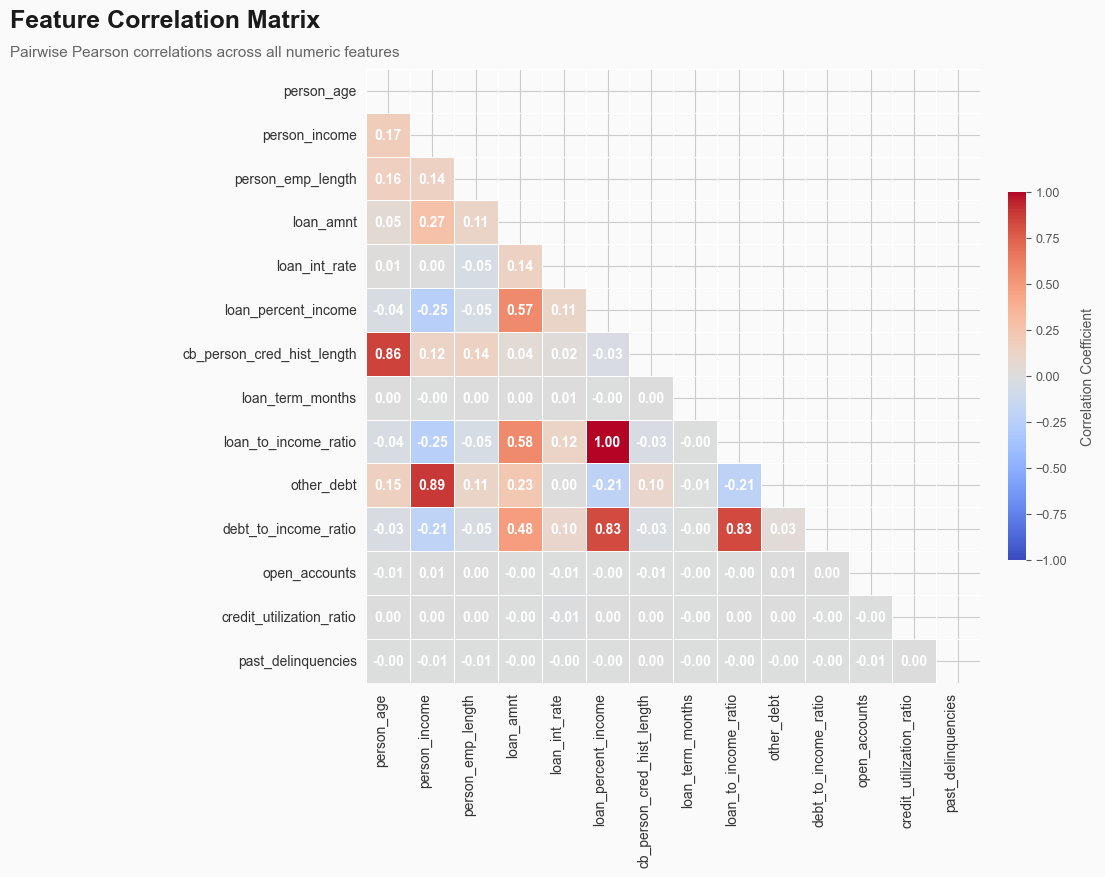

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# Drop lat/lon and compute correlation matrix
corr = df.drop(columns=['city_latitude', 'city_longitude']).corr(numeric_only=True)

# Mask upper triangle for cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))

# Figure setup
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Draw heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold", "color": "white"},
    cbar_kws={
        "shrink": 0.6,
        "aspect": 20,
        "pad": 0.02,
        "label": "Correlation Coefficient"
    },
    square=True,
    ax=ax
)

# Title & subtitle
fig.text(
    0.13, 0.97,
    "Feature Correlation Matrix",
    fontsize=18, fontweight='bold', color='#1a1a1a', va='top'
)
fig.text(
    0.13, 0.93,
    "Pairwise Pearson correlations across all numeric features",
    fontsize=11, color='#666666', va='top'
)

# Axis label styling
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90, ha='right',
    fontsize=10, color='#333333'
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10, color='#333333'
)
ax.tick_params(left=False, bottom=False)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9, colors='#555555')
cbar.set_label("Correlation Coefficient", fontsize=10, color='#555555', labelpad=10)
cbar.outline.set_edgecolor('#cccccc')

# Border cleanup
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Multivariate Analysis

### Feature Engineering

In [32]:
# Risk category
# converting raw numerical data into business-friendly categories to make risk analysis clearer and more actionable.


df['risk_level'] = pd.cut(df['loan_to_income_ratio'],
                         bins=[0, 0.2, 0.4, 1],
                         labels=['Low', 'Medium', 'High'])

# Age group
df['age_group'] = pd.cut(df['person_age'],
                        bins=[18, 30, 45, 60, 100],
                        labels=['Young', 'Mid', 'Senior', 'Old'])

### Segment Borrowers (Clustering Insight)

In [33]:
# It standardizes (scales) your numerical data
from sklearn.preprocessing import StandardScaler

# It groups data into clusters (segments)
from sklearn.cluster import KMeans

In [34]:

# scale key financial features and used KMeans to group borrowers into 3 clusters based on similarity.

features = df[['person_income', 'loan_amnt', 'debt_to_income_ratio']]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled)




In [35]:

# group by cluster and compute mean for the selected feature columns
cluster_profile = df.groupby('cluster')[features.columns].mean()
cluster_profile


,person_income,loan_amnt,debt_to_income_ratio
cluster,,,
0,"62,750.83","5,886.64",0.26
1,"123,257.79","20,543.51",0.38
2,"44,872.19","10,979.33",0.48


The clustering analysis revealed three distinct borrower segments. Cluster 2 appears to represent the highest-risk borrowers due to lower income levels and significantly higher debt-to-income ratios, while Cluster 0 represents relatively safer borrowers with lower debt burdens and smaller loan amounts.

In [40]:

# Which cluster actually defaults the most?
pd.crosstab(df['cluster'], df['loan_status'], normalize='index')


loan_status,0,1
cluster,,
0,0.86,0.14
1,0.78,0.22
2,0.65,0.35


In [41]:
risk_cluster_table = pd.crosstab(df['cluster'], df['risk_level'], margins=True, normalize='index') * 100
print(risk_cluster_table)

risk_level   Low  Medium  High
cluster                       
0          94.02    5.98  0.00
1          50.46   44.59  4.95
2          30.56   59.89  9.54
All        68.16   28.19  3.66


Above shows the percentage distribution of risk levels within each cluster. In simple terms:

For each borrower cluster,it shows how many borrowers are:
* Low risk
* Medium risk
* High risk

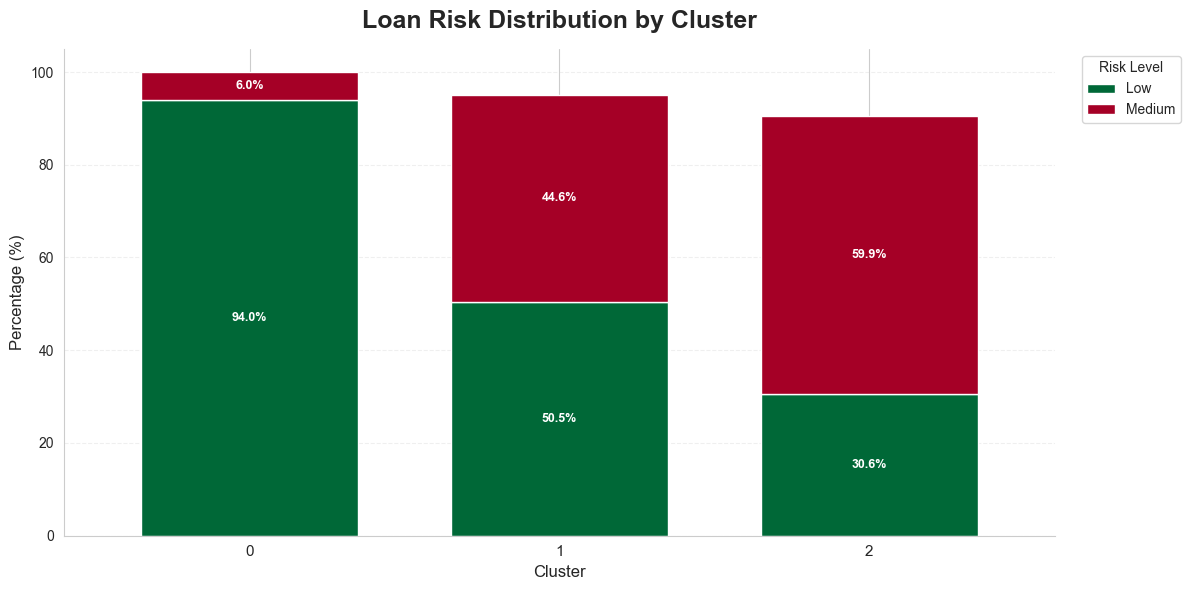

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

# Plot data (remove totals row/column)
plot_data = risk_cluster_table.iloc[:-1, :-1]

# Create figure
ax = plot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='RdYlGn_r',
    edgecolor='white',
    width=0.7
)

# Titles and labels
plt.title(
    'Loan Risk Distribution by Cluster',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Format y-axis
plt.yticks(fontsize=10)
plt.xticks(rotation=0, fontsize=11)

# Add subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove top/right borders
sns.despine()

# Add percentage labels inside bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

# Legend formatting
plt.legend(
    title='Risk Level',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.tight_layout()
plt.show()

In [45]:
age_risk_table = pd.crosstab(df['age_group'], df['risk_level'], margins=True, normalize='index') * 100
print(age_risk_table)

risk_level   Low  Medium  High
age_group                     
Young      67.45   28.83  3.71
Mid        70.29   26.22  3.49
Senior     72.51   24.74  2.75
Old        67.69   24.62  7.69
All        68.16   28.18  3.66


C:\Users\kwart\AppData\Local\Temp\ipykernel_21512\2529476033.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


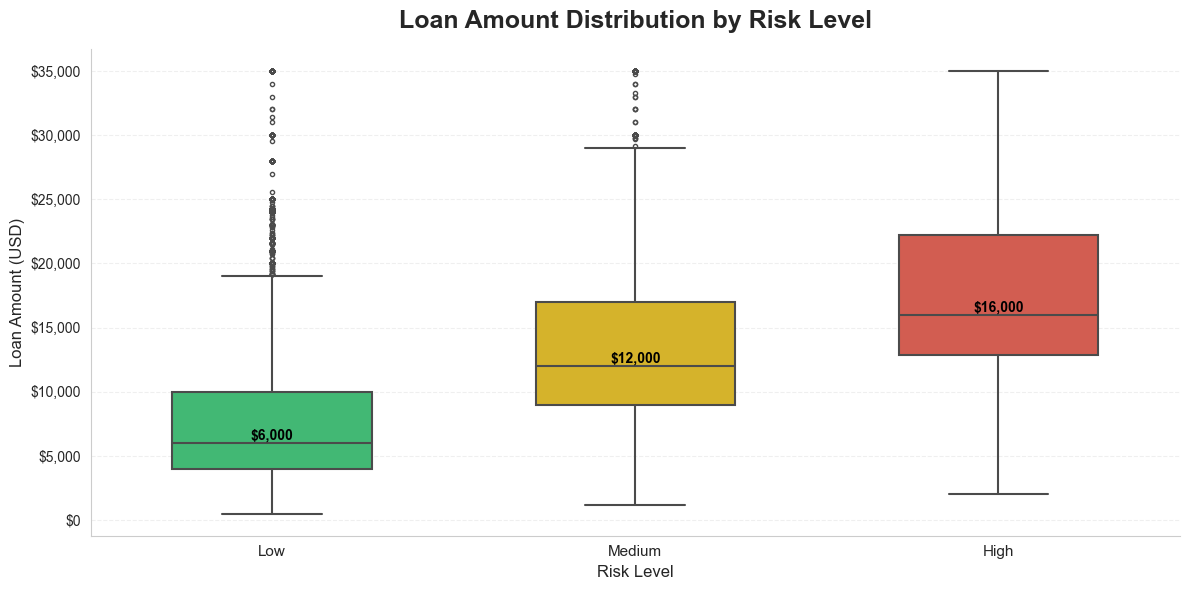

In [47]:


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# Style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(12, 6), dpi=100)

# Boxplot
ax = sns.boxplot(
    x='risk_level',
    y='loan_amnt',
    data=df,
    order=['Low', 'Medium', 'High'],
    palette=['#2ECC71', '#F1C40F', '#E74C3C'],  # Green → Yellow → Red
    width=0.55,
    linewidth=1.5,
    fliersize=3
)

# Titles and labels
plt.title(
    'Loan Amount Distribution by Risk Level',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Risk Level', fontsize=12)
plt.ylabel('Loan Amount (USD)', fontsize=12)

# Format y-axis with commas
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Add subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove unnecessary borders
sns.despine()

# Improve tick styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

# Add median values on plot
medians = df.groupby('risk_level', observed=True)['loan_amnt'].median()

for i, median in enumerate(medians):
    plt.text(
        i,
        median,
        f'${median:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()



In [ ]:
# calculates the percentage composition of age groups within each borrower cluster.


# This helps answer questions like:

# Which age groups dominate risky clusters?
# Are younger borrowers more financially stressed?
# Do older borrowers belong to safer clusters?


cluster_age_table = pd.crosstab(
    df['cluster'],
    df['age_group'],
    normalize='index'
) * 100

print(cluster_age_table)

age_group  Young   Mid  Senior  Old
cluster                            
0          76.35 21.67    1.81 0.17
1          72.05 25.36    2.17 0.42
2          77.91 20.38    1.57 0.14


All clusters are dominated by Young borrowers. More than 70% of borrowers in every cluster fall into the “Young” category.


This suggests:

* The loan portfolio is heavily concentrated among younger applicants.
* Younger individuals are the primary users of loans in the dataset.


The clustering analysis shows that the borrower population is predominantly young across all segments. Cluster 2 contains the highest proportion of young borrowers, which may indicate that younger applicants are more associated with financially stressed borrower profiles.

In [50]:
pd.crosstab(
    [df['cluster'], df['age_group']],
    df['risk_level'],
    margins=True,
    normalize='index'
) * 100

risk_level          Low  Medium  High
cluster age_group                    
0       Young     93.87    6.13  0.00
        Mid       94.43    5.57  0.00
        Senior    95.96    4.04  0.00
        Old       90.32    9.68  0.00
1       Young     47.54   47.40  5.06
        Mid       58.06   37.38  4.57
        Senior    58.25   38.83  2.91
        Old       55.00   25.00 20.00
2       Young     30.15   60.26  9.60
        Mid       31.88   58.67  9.45
        Senior    33.76   57.96  8.28
        Old       35.71   57.14  7.14
All               68.16   28.18  3.66

The analysis reveals clear differences in risk composition across borrower clusters. Cluster 0 consists almost entirely of low-risk borrowers, while Cluster 2 contains the highest proportion of medium- and high-risk borrowers across all age groups. Younger borrowers appear more concentrated within riskier borrower segments, suggesting that financial stress may be more common among younger applicants.

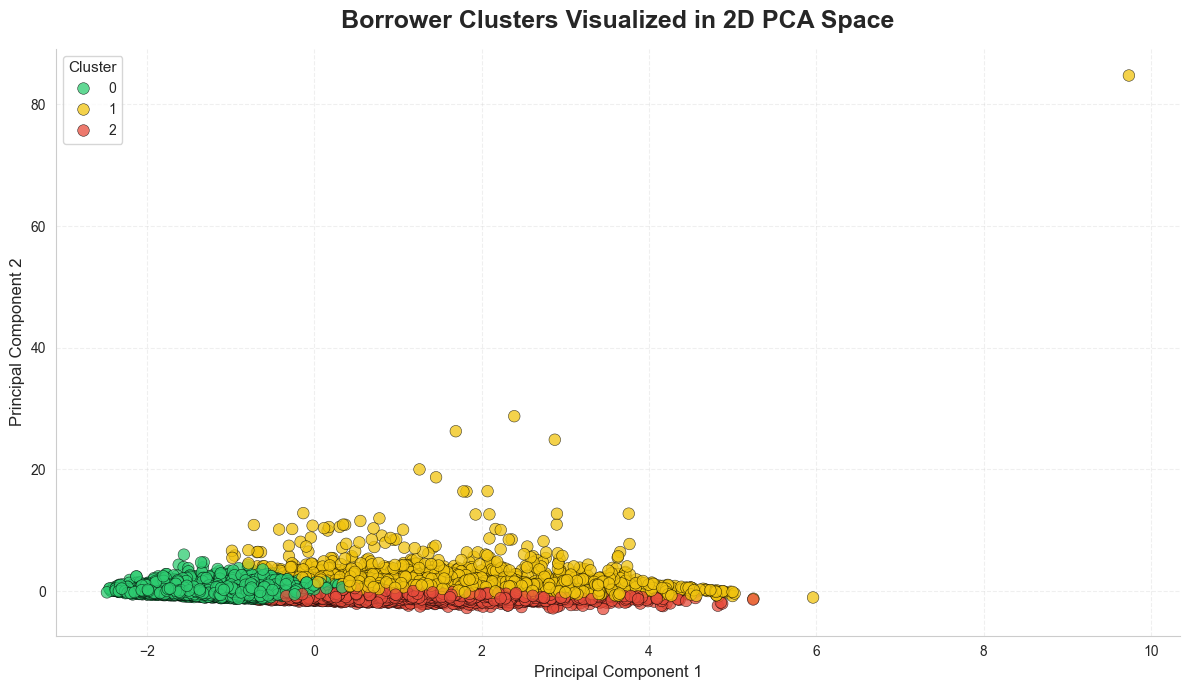

In [ ]:
# how borrowers are grouped into different financial clusters based on similarities in their financial characteristics.

# The positions of the dots are based on:

# income
# loan amount
# debt-to-income ratio

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# -----------------------------
# PCA Transformation
# -----------------------------
pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

df['pca1'] = components[:, 0]
df['pca2'] = components[:, 1]

# -----------------------------
# Plot Styling
# -----------------------------
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7), dpi=100)

# Scatterplot
ax = sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    data=df,
    palette=['#2ECC71', '#F1C40F', '#E74C3C'],
    s=70,              # marker size
    alpha=0.75,        # transparency
    edgecolor='black',
    linewidth=0.4
)

# Titles and labels
plt.title(
    'Borrower Clusters Visualized in 2D PCA Space',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Improve legend
plt.legend(
    title='Cluster',
    fontsize=10,
    title_fontsize=11,
    frameon=True
)

# Add subtle grid
plt.grid(linestyle='--', alpha=0.3)

# Remove unnecessary borders
sns.despine()

# Improve ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()